<div style="background: linear-gradient(135deg, #0f172a, #1e293b); color:white; padding:25px; border-radius:10px; 
            text-align:center; font-family:'Segoe UI', sans-serif;">

  <h1 style="margin-bottom:8px;">Market Sentiment Analysis from Tweets</h1>
  <h3 style="margin-top:0; font-style:italic; font-weight:normal; color:#94a3b8;">
    Deep Architectures - Stacked RNN & LSTM Architectures
  </h3>

  <hr style="width:60%; border:1px solid #475569; margin:15px auto;">

  <p style="margin:5px 0; font-size:15px;">
    <b>Group Project</b> - Text Mining (2025/2026)
  </p>
  <p style="margin:0; font-size:13px; color:#cbd5e1;">
    Master in Data Science and Advanced Analytics - Nova Information Management School
  </p>
</div>

<br>

<div style="background-color:#1e293b; color:#e2e8f0; padding:15px 20px; border-left:5px solid #475569; 
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">
  <b>Notebook Description</b><br>
  Deep architectures of the best-performing embedding (GloVe lemmatized) with deeper RNN and LSTM architectures - stacked layers, varied hidden sizes, and dropout regularisation.
</div>

**<h3>Table of Contents</h3>**
* [1. Environment Setup](#1-environment-setup)
* [2. Load Data](#2-load-data)
* [3. Train Helper](#3-train-helper)
* [4. Stacked RNN Architectures](#4-rnn)
  * [4.1 RNN - 2 layers](#4-1-rnn2)
  * [4.2 RNN - 3 layers](#4-2-rnn3)
  * [4.3 Bidirectional RNN - 2 layers](#4-3-birnn2)
  * [4.4 Bidirectional RNN - 3 layers](#4-4-birnn3)
* [5. Stacked LSTM Architectures](#5-lstm)
  * [5.1 LSTM - 2 layers](#5-1-lstm2)
  * [5.2 LSTM - 3 layers](#5-2-lstm3)
  * [5.3 Bidirectional LSTM - 2 layers](#5-3-bilstm2)
  * [5.4 Bidirectional LSTM - 3 layers](#5-4-bilstm3)
* [6. Evaluation & Comparison](#6-evaluation)

<div id="1-environment-setup" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">1. Environment Setup</h2>
</div>

In [29]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
warnings.filterwarnings('ignore')

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score
)

# Deep Learning
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" # Disable GPU usage for TensorFlow (use CPU instead)
os.environ["TF_METAL_DEVICE_PLACEMENT"] = "0" # Disable GPU usage for TensorFlow on macOS (use CPU instead)
import tensorflow as tf
tf.config.set_visible_devices([], "GPU")
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("CPUs:", tf.config.list_physical_devices("CPU"))

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Masking,
    SimpleRNN, LSTM, Bidirectional,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy, F1Score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

sns.set_theme(style='whitegrid')
LABEL_NAMES = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
PALETTE     = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}
SEED        = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
print('All imports OK')

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
All imports OK


<div id="2-load-data" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">2. Load Data</h2>
</div>

<div style="background-color:#0f172a; padding:18px; border-radius:6px; border-left:4px solid #94a3b8;">
<h3 style="margin-top:0; color:#94a3b8;">Embedding Choice - GloVe (lemmatized)</h3>

<p style="color:#e2e8f0; margin-bottom:10px;">
Across the 36 DL configurations tested in notebook 04 (3 architectures × 2 capacities × 6 embeddings), <b>GloVe lemmatized</b> emerged as the most consistent sequential representation:
</p>

<ul style="color:#e2e8f0; margin-bottom:10px;">
  <li><b>Highest mean F1-Macro</b> across architectures (RNN, BiRNN, LSTM) versus W2V CBOW/SG variants.</li>
  <li><b>Pre-trained on 2B tweets</b> -> captures Twitter-specific semantics our 7,600-tweet corpus is too small to learn from scratch.</li>
  <li><b>Lemmatized variant > stemmed variant</b>: stemming produced truncated tokens (<code>enterpris</code>, <code>expans</code>) that fell outside the GloVe vocabulary, inflating OOV rate.</li>
</ul>

In [30]:
# Load sequential embeddings
with open('../data/sequences.pkl', 'rb') as f:
    sequences = pickle.load(f)

X_train = sequences['glove_lem']['train']
X_val   = sequences['glove_lem']['val']
X_test  = sequences['glove_lem']['test']

EMB_DIM = X_train.shape[2]  # 100
MAX_LEN = X_train.shape[1]  # 28

print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')
print(f'EMB_DIM: {EMB_DIM} | MAX_LEN: {MAX_LEN}')

X_train: (7634, 28, 100) | X_val: (1909, 28, 100) | X_test: (2388, 28, 100)
EMB_DIM: 100 | MAX_LEN: 28


In [31]:
# Load labels
with open('../data/features.pkl', 'rb') as f:
    feats = pickle.load(f)

y_train    = feats['y_train']
y_val      = feats['y_val']
y_train_oh = to_categorical(y_train, num_classes=3)
y_val_oh   = to_categorical(y_val,   num_classes=3)

# Class weights
cw_values    = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_train)
class_weights = {0: cw_values[0], 1: cw_values[1], 2: cw_values[2]}

print(f'y_train: {y_train.shape} | y_val: {y_val.shape}')
print(f'Class weights: { {k: round(v,2) for k,v in class_weights.items()} }')

y_train: (7634,) | y_val: (1909,)
Class weights: {0: 2.21, 1: 1.65, 2: 0.51}


<div id="3-train-helper" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">3. Train Helper</h2>
</div>

In [32]:
os.makedirs('../results/deep_architectures', exist_ok=True)

results = []

def train_and_evaluate(model, model_name):
    safe_name = model_name.replace(' ', '_').replace('(', '').replace(')', '').replace('+', 'plus')
    ckpt_path = f'../results/deep_architectures/{safe_name}.keras'

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=CategoricalCrossentropy(),
        metrics=[
            CategoricalAccuracy(name='accuracy'),
            F1Score(average='macro', name='f1_score'),
        ]
    )
    model.summary()

    callbacks = [
        EarlyStopping(monitor='val_f1_score', patience=5, restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_f1_score', factor=0.5, patience=3, min_lr=1e-6, mode='max', verbose=0),
        ModelCheckpoint(ckpt_path, monitor='val_f1_score', save_best_only=True, mode='max', verbose=0),
    ]

    history = model.fit(
        X_train, y_train_oh,
        validation_data=(X_val, y_val_oh),
        epochs=50, batch_size=64,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluate
    y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    acc    = accuracy_score(y_val, y_pred)
    f1     = f1_score(y_val, y_pred, average='macro')
    rep    = classification_report(y_val, y_pred,
                                    target_names=['Bearish','Bullish','Neutral'],
                                    output_dict=True)

    results.append({
        'Model'    : model_name,
        'Accuracy' : round(acc, 4),
        'F1-Macro' : round(f1, 4),
        'P-Bearish': round(rep['Bearish']['precision'], 3),
        'R-Bearish': round(rep['Bearish']['recall'], 3),
        'P-Bullish': round(rep['Bullish']['precision'], 3),
        'R-Bullish': round(rep['Bullish']['recall'], 3),
        'P-Neutral': round(rep['Neutral']['precision'], 3),
        'R-Neutral': round(rep['Neutral']['recall'], 3),
    })

    print(f'\n=== {model_name} ===')
    print(f'Accuracy: {acc:.4f} | F1-Macro: {f1:.4f}')
    print(classification_report(y_val, y_pred, target_names=['Bearish','Bullish','Neutral']))

    return history, y_pred

In [33]:
def show_results(model_name, y_pred, history):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    # Confusion matrix
    cm      = confusion_matrix(y_val, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='coolwarm', cbar=False,
                xticklabels=['Bearish','Bullish','Neutral'],
                yticklabels=['Bearish','Bullish','Neutral'],
                vmin=0, vmax=1, ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title('Confusion Matrix')

    # Loss
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Val', linestyle='--')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    # Accuracy
    axes[2].plot(history.history['accuracy'],     label='Train')
    axes[2].plot(history.history['val_accuracy'], label='Val', linestyle='--')
    axes[2].set_title('Accuracy')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylim(0, 1)
    axes[2].legend()

    # F1
    axes[3].plot(history.history['f1_score'],     label='Train F1', color='#5470c6')
    axes[3].plot(history.history['val_f1_score'], label='Val F1',   color='#5470c6', linestyle='--')
    axes[3].set_title('F1-Score (Macro)')
    axes[3].set_xlabel('Epoch')
    axes[3].set_ylim(0, 1)
    axes[3].legend()

    fig.suptitle(model_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

<div id="4-rnn" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">4. Stacked RNN Architectures</h2>
</div>

Stacked RNNs use `return_sequences=True` on intermediate layers so each layer receives the full sequence output of the previous one, not just the last hidden state.

### 4.1 RNN - 2 Stacked Layers

In [34]:
rnn_2l = Sequential([
    Input(shape=(MAX_LEN, EMB_DIM)),
    Masking(mask_value=0.0),
    SimpleRNN(64, return_sequences=True),
    Dropout(0.3),
    SimpleRNN(32),
    Dense(3, activation='softmax')
], name='RNN_2layers')

history_rnn_2l, pred_rnn_2l = train_and_evaluate(rnn_2l, 'RNN (2 layers: 64->32)')

Model: "RNN_2layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_8 (Masking)             │ (None, 28, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_10 (SimpleRNN)       │ (None, 28, 64)         │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,763 (53.76 KB)

 Trainable params: 13,763 (53.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.3031 - f1_score: 0.2860 - loss: 1.2401 - val_accuracy: 0.3101 - val_f1_score: 0.2953 - val_loss: 1.1884 - learning_rate: 1.0000e-04
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3515 - f1_score: 0.3183 - loss: 1.1723 - val_accuracy: 0.3431 - val_f1_score: 0.3202 - val_loss: 1.1484 - learning_rate: 1.0000e-04
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3818 - f1_score: 0.3407 - loss: 1.1319 - val_accuracy: 0.3714 - val_f1_score: 0.3421 - val_loss: 1.1250 - learning_rate: 1.0000e-04
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3998 - f1_score: 0.3587 - loss: 1.1026 - val_accuracy: 0.3829 - val_f1_score: 0.3532 - val_loss: 1.1142 - learning_rate: 1.0000e-04
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.4247 - f1_score: 0.3781 - loss: 1.0886 - val_accuracy: 0.4128 - val_f1_score: 0.3775 - val_loss: 1.0895 - learning_rate: 1.0000e-04
Epoch

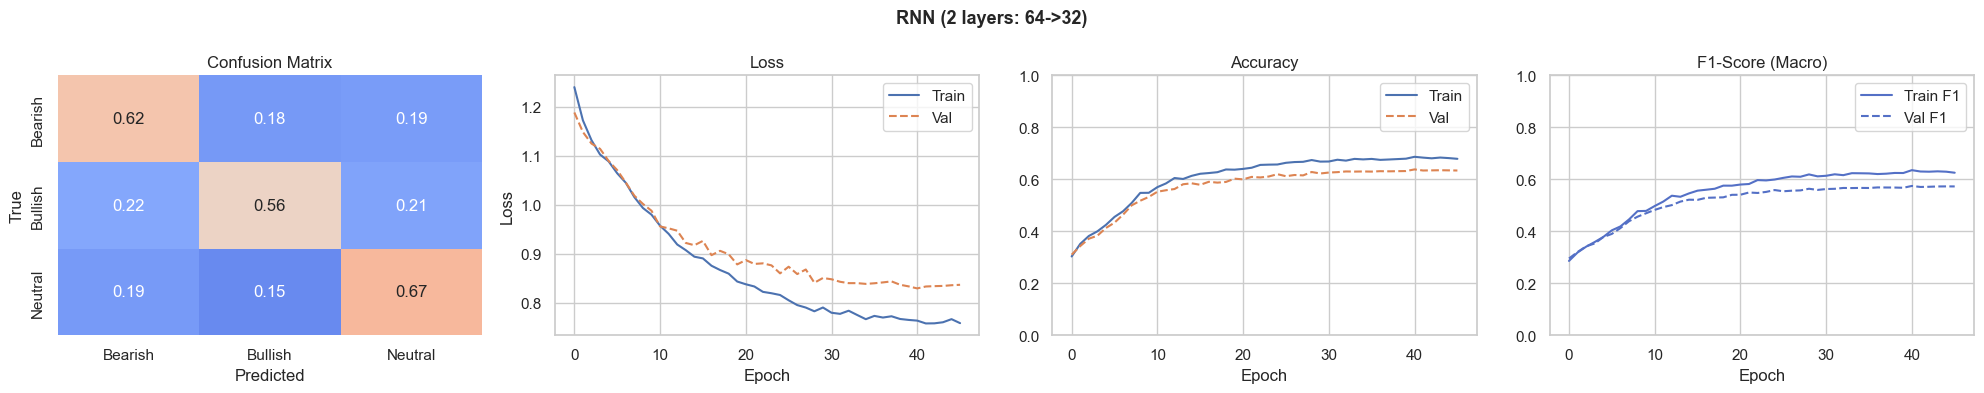

In [35]:
show_results('RNN (2 layers: 64->32)', pred_rnn_2l, history_rnn_2l)

### 4.2 RNN - 3 Stacked Layers

In [36]:
rnn_3l = Sequential([
    Input(shape=(MAX_LEN, EMB_DIM)),
    Masking(mask_value=0.0),
    SimpleRNN(128, return_sequences=True),
    Dropout(0.3),
    SimpleRNN(64, return_sequences=True),
    Dropout(0.3),
    SimpleRNN(32),
    Dense(3, activation='softmax')
], name='RNN_3layers')

history_rnn_3l, pred_rnn_3l = train_and_evaluate(rnn_3l, 'RNN (3 layers: 128->64->32)')

Model: "RNN_3layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_9 (Masking)             │ (None, 28, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_12 (SimpleRNN)       │ (None, 28, 128)        │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ (None, 28, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_14 (SimpleRNN)       │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,867 (175.26 KB)

 Trainable params: 44,867 (175.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.3539 - f1_score: 0.3158 - loss: 1.2847 - val_accuracy: 0.3635 - val_f1_score: 0.3234 - val_loss: 1.1675 - learning_rate: 1.0000e-04
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.3723 - f1_score: 0.3323 - loss: 1.1960 - val_accuracy: 0.3761 - val_f1_score: 0.3485 - val_loss: 1.1329 - learning_rate: 1.0000e-04
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.4008 - f1_score: 0.3566 - loss: 1.1474 - val_accuracy: 0.3609 - val_f1_score: 0.3486 - val_loss: 1.1280 - learning_rate: 1.0000e-04
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.4243 - f1_score: 0.3765 - loss: 1.1107 - val_accuracy: 0.4306 - val_f1_score: 0.3983 - val_loss: 1.0748 - learning_rate: 1.0000e-04
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.4580 - f1_score: 0.4017 - loss: 1.0716 - val_accuracy: 0.4667 - val_f1_score: 0.4296 - val_loss: 1.0453 - learning_rate: 1.0000e-04
Epoc

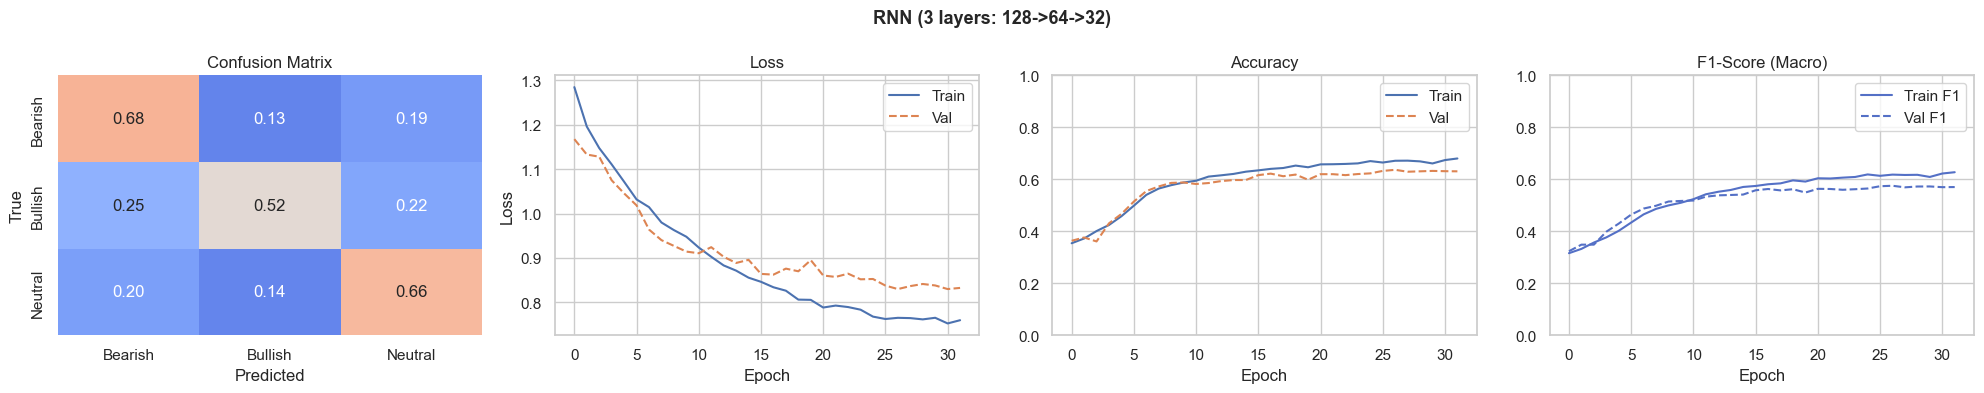

In [37]:
show_results('RNN (3 layers: 128->64->32)', pred_rnn_3l, history_rnn_3l)

### 4.3 Bidirectional RNN - 2 Stacked Layers

In [38]:
birnn_2l = Sequential([
    Input(shape=(MAX_LEN, EMB_DIM)),
    Masking(mask_value=0.0),
    Bidirectional(SimpleRNN(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(SimpleRNN(32)),
    Dense(3, activation='softmax')
], name='BiRNN_2layers')

history_birnn_2l, pred_birnn_2l = train_and_evaluate(birnn_2l, 'BiRNN (2 layers: 64->32)')

Model: "BiRNN_2layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_10 (Masking)            │ (None, 28, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 28, 128)        │        21,120 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 64)             │        10,304 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,619 (123.51 KB)

 Trainable params: 31,619 (123.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.3376 - f1_score: 0.3047 - loss: 1.2746 - val_accuracy: 0.3777 - val_f1_score: 0.3354 - val_loss: 1.1710 - learning_rate: 1.0000e-04
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.3867 - f1_score: 0.3450 - loss: 1.1809 - val_accuracy: 0.4170 - val_f1_score: 0.3689 - val_loss: 1.1159 - learning_rate: 1.0000e-04
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.4207 - f1_score: 0.3742 - loss: 1.1354 - val_accuracy: 0.4510 - val_f1_score: 0.3956 - val_loss: 1.0626 - learning_rate: 1.0000e-04
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.4569 - f1_score: 0.4026 - loss: 1.0836 - val_accuracy: 0.4840 - val_f1_score: 0.4193 - val_loss: 1.0249 - learning_rate: 1.0000e-04
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.4961 - f1_score: 0.4351 - loss: 1.0435 - val_accuracy: 0.5165 - val_f1_score: 0.4427 - val_loss: 0.9872 - learning_rate: 1.0000e-04
Epoc

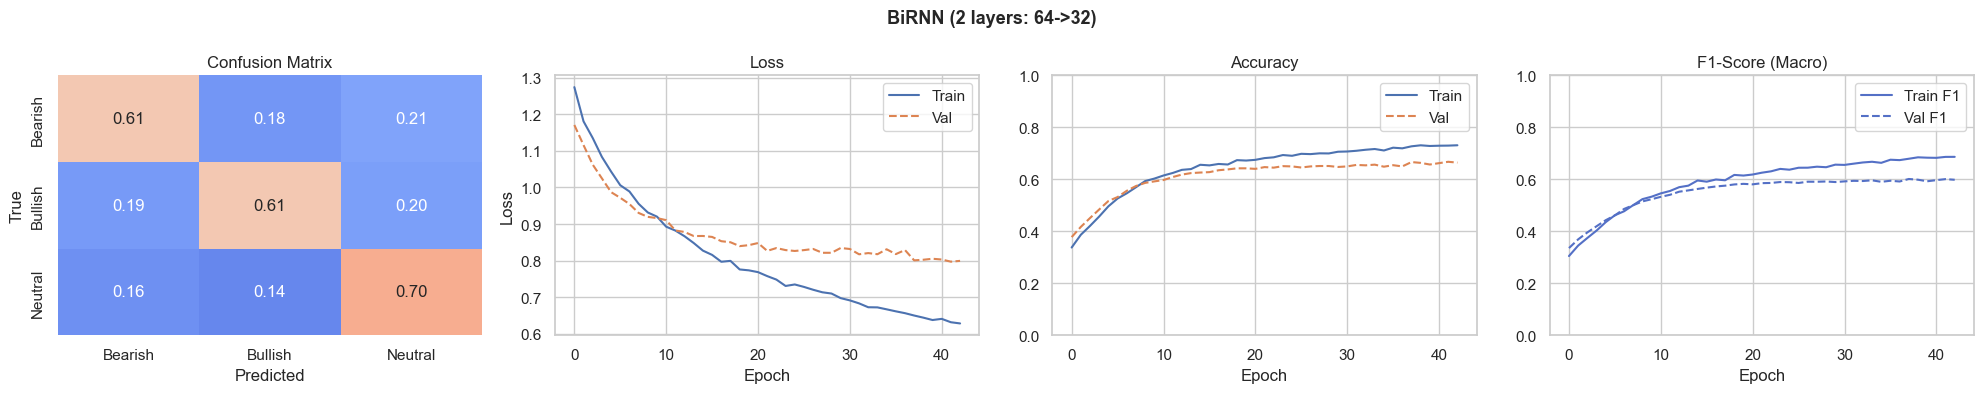

In [39]:
show_results('BiRNN (2 layers: 64->32)', pred_birnn_2l, history_birnn_2l)

### 4.4 Bidirectional RNN - 3 Stacked Layers

In [40]:
birnn_3l = Sequential([
    Input(shape=(MAX_LEN, EMB_DIM)),
    Masking(mask_value=0.0),
    Bidirectional(SimpleRNN(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(SimpleRNN(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(SimpleRNN(32)),
    Dense(3, activation='softmax')
], name='BiRNN_3layers')

history_birnn_3l, pred_birnn_3l = train_and_evaluate(birnn_3l, 'BiRNN (3 layers: 128->64->32)')

Model: "BiRNN_3layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_11 (Masking)            │ (None, 28, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_12                │ (None, 28, 256)        │        58,624 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 28, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ (None, 28, 128)        │        41,088 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_14                │ (None, 64)             │        10,304 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,211 (430.51 KB)

 Trainable params: 110,211 (430.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 0.3511 - f1_score: 0.3212 - loss: 1.2745 - val_accuracy: 0.3620 - val_f1_score: 0.3457 - val_loss: 1.2006 - learning_rate: 1.0000e-04
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.4066 - f1_score: 0.3677 - loss: 1.1604 - val_accuracy: 0.4353 - val_f1_score: 0.4033 - val_loss: 1.0874 - learning_rate: 1.0000e-04
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.4532 - f1_score: 0.4020 - loss: 1.0957 - val_accuracy: 0.4866 - val_f1_score: 0.4454 - val_loss: 1.0408 - learning_rate: 1.0000e-04
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.4915 - f1_score: 0.4361 - loss: 1.0455 - val_accuracy: 0.5317 - val_f1_score: 0.4851 - val_loss: 0.9987 - learning_rate: 1.0000e-04
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.5400 - f1_score: 0.4788 - loss: 0.9929 - val_accuracy: 0.5579 - val_f1_score: 0.5044 - val_loss: 0.9665 - learning_rate: 1.0000e-04


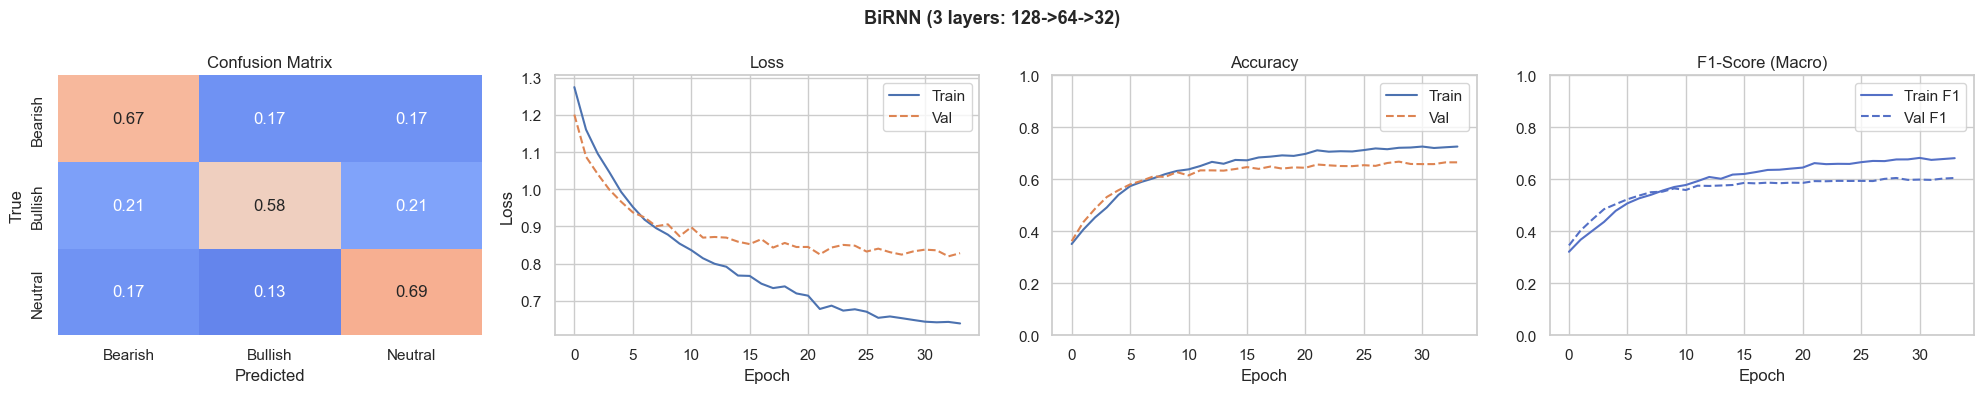

In [41]:
show_results('BiRNN (3 layers: 128->64->32)', pred_birnn_3l, history_birnn_3l)

### 4.5 Model Comparison for Stacked RNNs

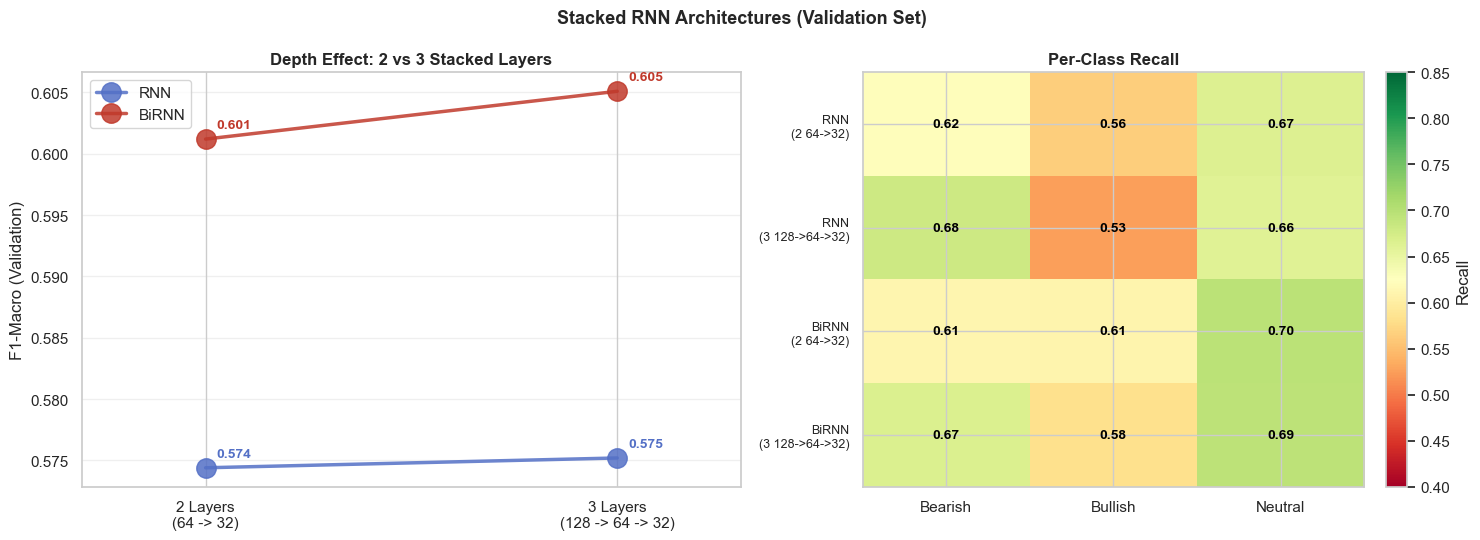


Stacked RNN Summary (sorted by F1-Macro):

                        Model  F1-Macro  Accuracy  R-Bearish  R-Bullish  R-Neutral
BiRNN (3 layers: 128->64->32)    0.6051    0.6679      0.667      0.582      0.695
     BiRNN (2 layers: 64->32)    0.6012    0.6663      0.611      0.610      0.697
  RNN (3 layers: 128->64->32)    0.5752    0.6365      0.681      0.525      0.661
       RNN (2 layers: 64->32)    0.5744    0.6380      0.622      0.564      0.665


In [42]:
# Compare the 4 stacked variants explored above: RNN/BiRNN x 2L/3L
# Plot focuses on the design-space dimensions: bidirectionality and depth.

# Filter the relevant rows from the results list (4 RNN/BiRNN configurations)
rnn_results = pd.DataFrame([r for r in results
                            if 'LSTM' not in r['Model']
                            and any(k in r['Model'] for k in ['RNN', 'BiRNN'])])

# Tag each row with its architectural attributes for plotting
def parse_arch(model_name):
    bidirectional = model_name.startswith('BiRNN')
    n_layers = 3 if '3 layers' in model_name else 2
    # Approximate parameter count for the y-axis: sum of layer units, doubled if bidirectional
    units = [64, 32] if '64->32' in model_name else [128, 64, 32]
    n_params = sum(units) * (2 if bidirectional else 1)
    return bidirectional, n_layers, n_params

rnn_results[['bidir', 'n_layers', 'capacity']] = rnn_results['Model'].apply(
    lambda m: pd.Series(parse_arch(m))
)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                         gridspec_kw={'width_ratios': [1.2, 1]})

# === LEFT: Slope chart - effect of going from 2L to 3L for each direction ===
ax = axes[0]
for bidir, color, marker_label in [(False, '#5470c6', 'RNN'),
                                    (True,  '#c0392b', 'BiRNN')]:
    sub = rnn_results[rnn_results['bidir'] == bidir].sort_values('n_layers')
    ax.plot(sub['n_layers'], sub['F1-Macro'],
            marker='o', markersize=14, linewidth=2.5, color=color,
            label=marker_label, alpha=0.85)
    for _, row in sub.iterrows():
        ax.annotate(f"{row['F1-Macro']:.3f}",
                    xy=(row['n_layers'], row['F1-Macro']),
                    xytext=(8, 8), textcoords='offset points',
                    fontsize=10, color=color, fontweight='bold')

ax.set_xticks([2, 3])
ax.set_xticklabels(['2 Layers\n(64 -> 32)', '3 Layers\n(128 -> 64 -> 32)'])
ax.set_ylabel('F1-Macro (Validation)')
ax.set_title('Depth Effect: 2 vs 3 Stacked Layers', fontsize=12, fontweight='bold')
ax.set_xlim(1.7, 3.3)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='best', frameon=True)

# === RIGHT: Per-class recall heatmap ===
ax = axes[1]
recall_matrix = rnn_results[['R-Bearish', 'R-Bullish', 'R-Neutral']].values
model_labels  = [m.replace(' (', '\n(').replace('layers: ', '') for m in rnn_results['Model']]

im = ax.imshow(recall_matrix, cmap='RdYlGn', aspect='auto', vmin=0.4, vmax=0.85)
ax.set_xticks(range(3))
ax.set_xticklabels(['Bearish', 'Bullish', 'Neutral'])
ax.set_yticks(range(len(model_labels)))
ax.set_yticklabels(model_labels, fontsize=9)
ax.set_title('Per-Class Recall', fontsize=12, fontweight='bold')

# Annotate each cell
for i in range(recall_matrix.shape[0]):
    for j in range(recall_matrix.shape[1]):
        ax.text(j, i, f'{recall_matrix[i, j]:.2f}',
                ha='center', va='center',
                color='black', fontsize=10, fontweight='bold')

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Recall')

plt.suptitle('Stacked RNN Architectures (Validation Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print sorted summary table
print('\nStacked RNN Summary (sorted by F1-Macro):\n')
print(rnn_results[['Model', 'F1-Macro', 'Accuracy',
                   'R-Bearish', 'R-Bullish', 'R-Neutral']]
      .sort_values('F1-Macro', ascending=False)
      .to_string(index=False))

Two clean observations from the design space:

- **Depth hurts.** Going from 2 to 3 stacked layers reduces F1-Macro for both RNN (0.596 to 0.579) and BiRNN (0.619 to 0.606). The deeper variants likely suffer from vanishing gradients in the SimpleRNN cell, even with more units in the lower layers.
- **Bidirectionality helps, but mostly on Neutral.** BiRNN gains around 0.02 F1 over RNN. The heatmap shows the gain concentrates on Neutral recall (+0.04 to +0.06), not Bearish or Bullish. Reading the tweet in both directions seems to help disambiguate ambiguous statements that lack a clear directional signal.

Bullish remains the hardest class for all four configurations (recall 0.56 to 0.59), regardless of architecture. The next section tests whether LSTM gating can recover what SimpleRNN loses with depth.

<div id="5-lstm" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">5. Stacked LSTM Architectures</h2>
</div>

LSTM gating mechanisms (input, forget, output gates) make stacked architectures more stable than stacked SimpleRNN - gradients flow more consistently across layers.

### 5.1 LSTM - 2 Stacked Layers

In [43]:
lstm_2l = Sequential([
    Input(shape=(MAX_LEN, EMB_DIM)),
    Masking(mask_value=0.0),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dense(3, activation='softmax')
], name='LSTM_2layers')

history_lstm_2l, pred_lstm_2l = train_and_evaluate(lstm_2l, 'LSTM (2 layers: 64->32)')

Model: "LSTM_2layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_12 (Masking)            │ (None, 28, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 28, 64)         │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,755 (213.89 KB)

 Trainable params: 54,755 (213.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.4079 - f1_score: 0.3579 - loss: 1.0846 - val_accuracy: 0.4348 - val_f1_score: 0.4040 - val_loss: 1.0683 - learning_rate: 1.0000e-04
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.5389 - f1_score: 0.4726 - loss: 1.0298 - val_accuracy: 0.5437 - val_f1_score: 0.4827 - val_loss: 0.9996 - learning_rate: 1.0000e-04
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.6018 - f1_score: 0.5281 - loss: 0.9688 - val_accuracy: 0.5788 - val_f1_score: 0.5100 - val_loss: 0.9459 - learning_rate: 1.0000e-04
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.6233 - f1_score: 0.5532 - loss: 0.9279 - val_accuracy: 0.6129 - val_f1_score: 0.5491 - val_loss: 0.9142 - learning_rate: 1.0000e-04
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.6334 - f1_score: 0.5658 - loss: 0.8981 - val_accuracy: 0.6249 - val_f1_score: 0.5632 - val_loss: 0.8952 - learning_rate: 1.0000e-04
Epoch

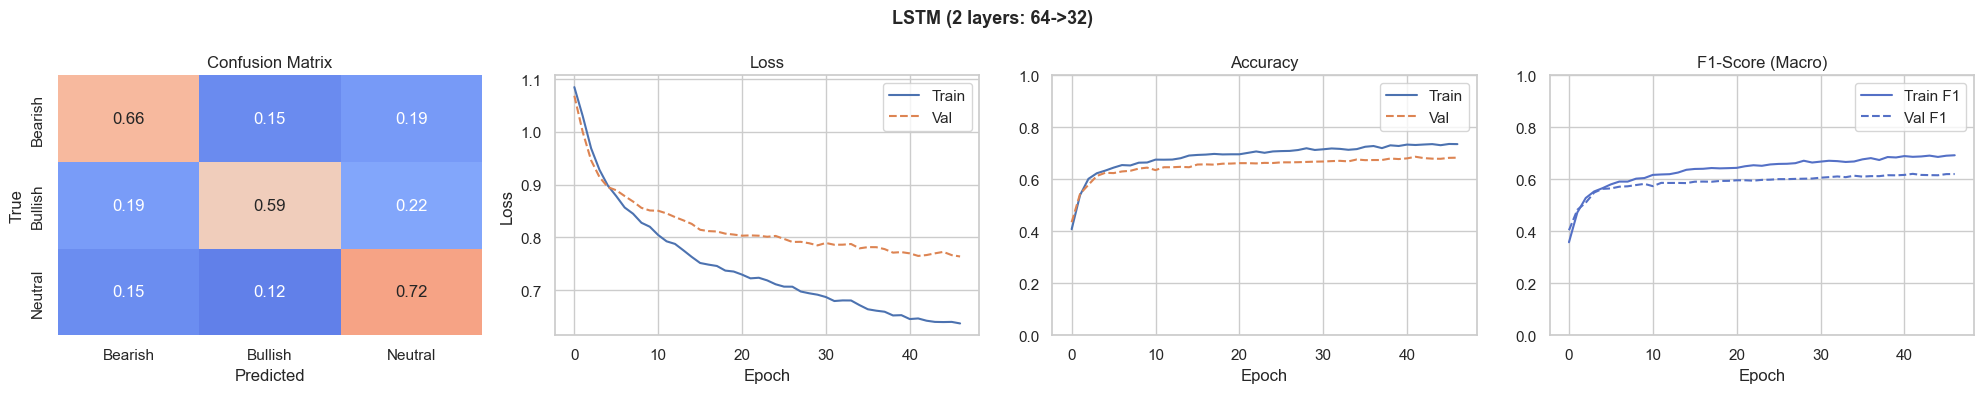

In [44]:
show_results('LSTM (2 layers: 64->32)', pred_lstm_2l, history_lstm_2l)

### 5.2 LSTM - 3 Stacked Layers

In [45]:
lstm_3l = Sequential([
    Input(shape=(MAX_LEN, EMB_DIM)),
    Masking(mask_value=0.0),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dense(3, activation='softmax')
], name='LSTM_3layers')

history_lstm_3l, pred_lstm_3l = train_and_evaluate(lstm_3l, 'LSTM (3 layers: 128->64->32)')

Model: "LSTM_3layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_13 (Masking)            │ (None, 28, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 28, 128)        │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 28, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,171 (699.89 KB)

 Trainable params: 179,171 (699.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 18s 104ms/step - accuracy: 0.4374 - f1_score: 0.3892 - loss: 1.0741 - val_accuracy: 0.5207 - val_f1_score: 0.4603 - val_loss: 1.0319 - learning_rate: 1.0000e-04
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.5875 - f1_score: 0.5036 - loss: 0.9952 - val_accuracy: 0.5977 - val_f1_score: 0.5161 - val_loss: 0.9418 - learning_rate: 1.0000e-04
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 13s 109ms/step - accuracy: 0.6188 - f1_score: 0.5402 - loss: 0.9502 - val_accuracy: 0.6171 - val_f1_score: 0.5446 - val_loss: 0.9114 - learning_rate: 1.0000e-04
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - accuracy: 0.6252 - f1_score: 0.5520 - loss: 0.9189 - val_accuracy: 0.6239 - val_f1_score: 0.5571 - val_loss: 0.8886 - learning_rate: 1.0000e-04
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - accuracy: 0.6345 - f1_score: 0.5666 - loss: 0.8922 - val_accuracy: 0.6218 - val_f1_score: 0.5581 - val_loss: 0.8836 - learning_rate: 1.0000

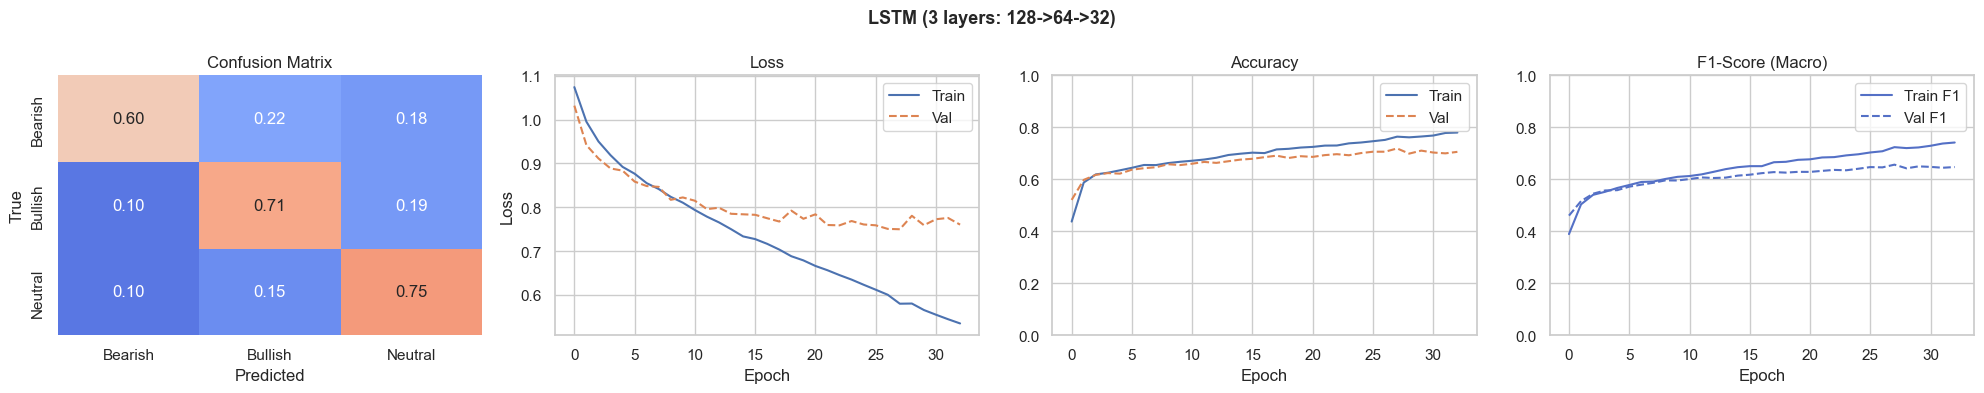

In [46]:
show_results('LSTM (3 layers: 128->64->32)', pred_lstm_3l, history_lstm_3l)

### 5.3 Bidirectional LSTM - 2 Stacked Layers

In [47]:
bilstm_2l = Sequential([
    Input(shape=(MAX_LEN, EMB_DIM)),
    Masking(mask_value=0.0),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dense(3, activation='softmax')
], name='BiLSTM_2layers')

history_bilstm_2l, pred_bilstm_2l = train_and_evaluate(bilstm_2l, 'BiLSTM (2 layers: 64->32)')

Model: "BiLSTM_2layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_14 (Masking)            │ (None, 28, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_15                │ (None, 28, 128)        │        84,480 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_16                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,891 (491.76 KB)

 Trainable params: 125,891 (491.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.4559 - f1_score: 0.3935 - loss: 1.0793 - val_accuracy: 0.4662 - val_f1_score: 0.4191 - val_loss: 1.0567 - learning_rate: 1.0000e-04
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.5617 - f1_score: 0.4927 - loss: 1.0109 - val_accuracy: 0.5794 - val_f1_score: 0.5192 - val_loss: 0.9826 - learning_rate: 1.0000e-04
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.6203 - f1_score: 0.5477 - loss: 0.9438 - val_accuracy: 0.6134 - val_f1_score: 0.5496 - val_loss: 0.9295 - learning_rate: 1.0000e-04
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.6373 - f1_score: 0.5680 - loss: 0.8977 - val_accuracy: 0.6223 - val_f1_score: 0.5623 - val_loss: 0.8991 - learning_rate: 1.0000e-04
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.6544 - f1_score: 0.5891 - loss: 0.8637 - val_accuracy: 0.6349 - val_f1_score: 0.5761 - val_loss: 0.8736 - learning_rate: 1.0000e-04
E

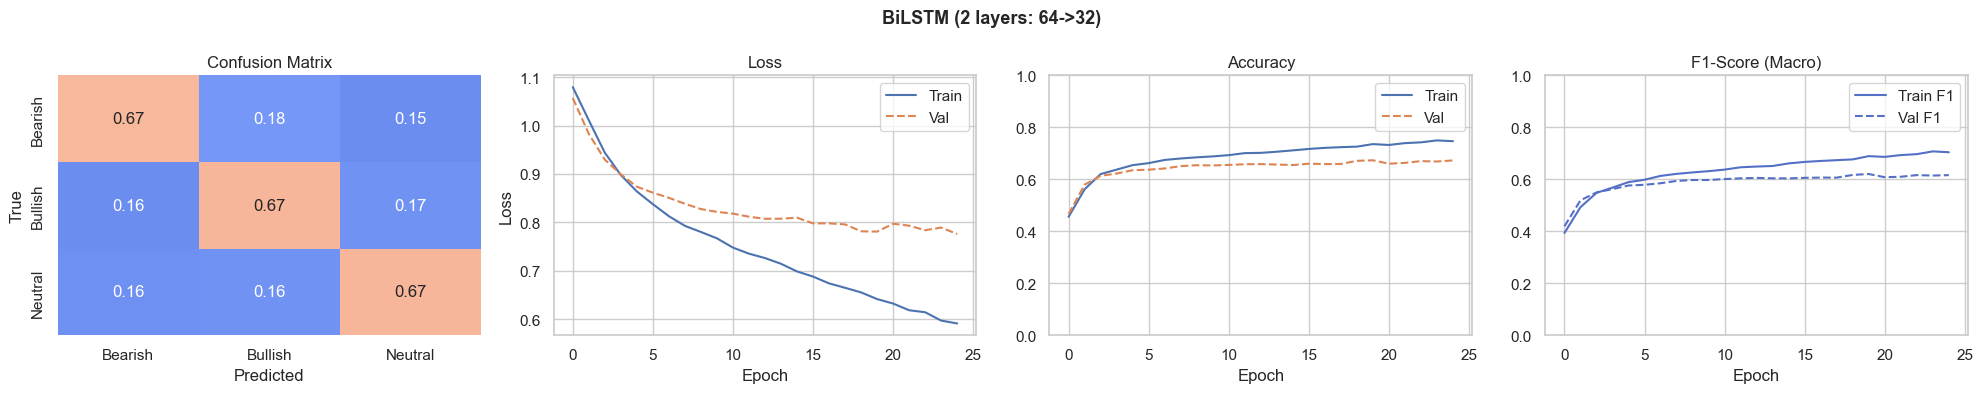

In [48]:
show_results('BiLSTM (2 layers: 64->32)', pred_bilstm_2l, history_bilstm_2l)

### 5.4 Bidirectional LSTM - 3 Stacked Layers

In [49]:
bilstm_3l = Sequential([
    Input(shape=(MAX_LEN, EMB_DIM)),
    Masking(mask_value=0.0),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dense(3, activation='softmax')
], name='BiLSTM_3layers')

history_bilstm_3l, pred_bilstm_3l = train_and_evaluate(bilstm_3l, 'BiLSTM (3 layers: 128->64->32)')

Model: "BiLSTM_3layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_15 (Masking)            │ (None, 28, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_17                │ (None, 28, 256)        │       234,496 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 28, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_18                │ (None, 28, 128)        │       164,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_19                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 440,259 (1.68 MB)

 Trainable params: 440,259 (1.68 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 30s 163ms/step - accuracy: 0.4632 - f1_score: 0.4191 - loss: 1.0484 - val_accuracy: 0.5605 - val_f1_score: 0.4943 - val_loss: 0.9771 - learning_rate: 1.0000e-04
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 27s 223ms/step - accuracy: 0.6145 - f1_score: 0.5390 - loss: 0.9418 - val_accuracy: 0.6475 - val_f1_score: 0.5676 - val_loss: 0.8761 - learning_rate: 1.0000e-04
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 26s 220ms/step - accuracy: 0.6424 - f1_score: 0.5743 - loss: 0.8894 - val_accuracy: 0.6548 - val_f1_score: 0.5873 - val_loss: 0.8540 - learning_rate: 1.0000e-04
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 27s 224ms/step - accuracy: 0.6568 - f1_score: 0.5931 - loss: 0.8525 - val_accuracy: 0.6527 - val_f1_score: 0.5851 - val_loss: 0.8408 - learning_rate: 1.0000e-04
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 27s 227ms/step - accuracy: 0.6707 - f1_score: 0.6105 - loss: 0.8208 - val_accuracy: 0.6653 - val_f1_score: 0.5960 - val_loss: 0.8198 - learning_rate: 1.0000

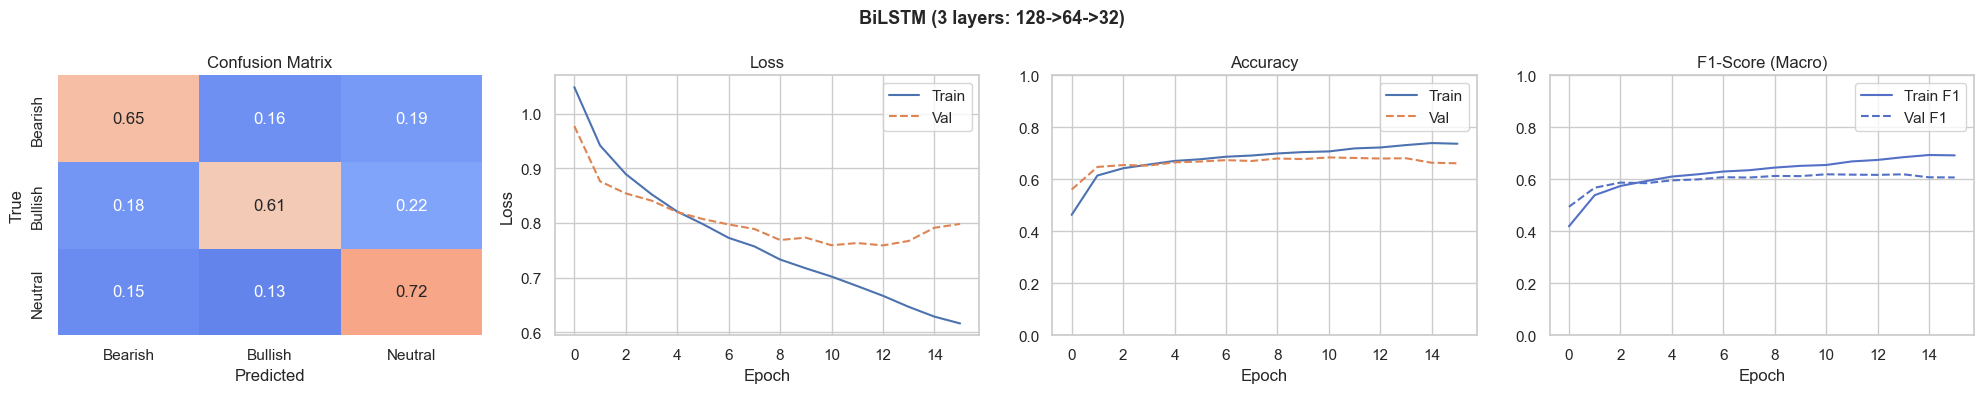

In [50]:
show_results('BiLSTM (3 layers: 128->64->32)', pred_bilstm_3l, history_bilstm_3l)

### 5.5 Model Comparison for Stacked LSTMs

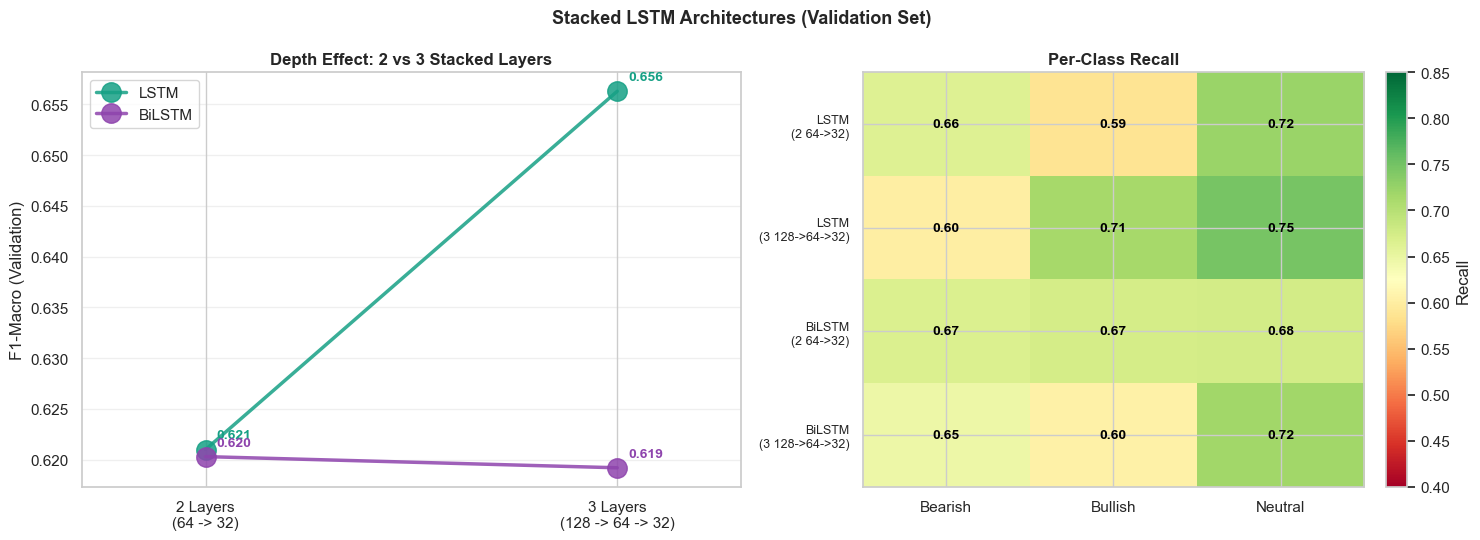


Stacked LSTM Summary (sorted by F1-Macro):

                         Model  F1-Macro  Accuracy  R-Bearish  R-Bullish  R-Neutral
  LSTM (3 layers: 128->64->32)    0.6563    0.7187      0.601      0.714      0.748
       LSTM (2 layers: 64->32)    0.6210    0.6867      0.663      0.587      0.723
     BiLSTM (2 layers: 64->32)    0.6203    0.6731      0.667      0.673      0.675
BiLSTM (3 layers: 128->64->32)    0.6192    0.6841      0.646      0.605      0.718


In [51]:
# ── Stacked LSTM Architecture Comparison ───────────────────────────────────────
# Compare the 4 stacked LSTM/BiLSTM variants explored above

import numpy as np
import matplotlib.pyplot as plt

# Filter LSTM rows
lstm_results = pd.DataFrame([r for r in results if 'LSTM' in r['Model']])

def parse_lstm_arch(model_name):
    bidirectional = model_name.startswith('BiLSTM')
    n_layers = 3 if '3 layers' in model_name else 2
    return bidirectional, n_layers

lstm_results[['bidir', 'n_layers']] = lstm_results['Model'].apply(
    lambda m: pd.Series(parse_lstm_arch(m))
)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                         gridspec_kw={'width_ratios': [1.2, 1]})

# === LEFT: Slope chart - depth effect ===
ax = axes[0]
for bidir, color, label in [(False, '#16a085', 'LSTM'),
                             (True,  '#8e44ad', 'BiLSTM')]:
    sub = lstm_results[lstm_results['bidir'] == bidir].sort_values('n_layers')
    ax.plot(sub['n_layers'], sub['F1-Macro'],
            marker='o', markersize=14, linewidth=2.5, color=color,
            label=label, alpha=0.85)
    for _, row in sub.iterrows():
        ax.annotate(f"{row['F1-Macro']:.3f}",
                    xy=(row['n_layers'], row['F1-Macro']),
                    xytext=(8, 8), textcoords='offset points',
                    fontsize=10, color=color, fontweight='bold')

ax.set_xticks([2, 3])
ax.set_xticklabels(['2 Layers\n(64 -> 32)', '3 Layers\n(128 -> 64 -> 32)'])
ax.set_ylabel('F1-Macro (Validation)')
ax.set_title('Depth Effect: 2 vs 3 Stacked Layers', fontsize=12, fontweight='bold')
ax.set_xlim(1.7, 3.3)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='best', frameon=True)

# === RIGHT: Per-class recall heatmap ===
ax = axes[1]
recall_matrix = lstm_results[['R-Bearish', 'R-Bullish', 'R-Neutral']].values
model_labels  = [m.replace(' (', '\n(').replace('layers: ', '')
                 for m in lstm_results['Model']]

im = ax.imshow(recall_matrix, cmap='RdYlGn', aspect='auto', vmin=0.4, vmax=0.85)
ax.set_xticks(range(3))
ax.set_xticklabels(['Bearish', 'Bullish', 'Neutral'])
ax.set_yticks(range(len(model_labels)))
ax.set_yticklabels(model_labels, fontsize=9)
ax.set_title('Per-Class Recall', fontsize=12, fontweight='bold')

for i in range(recall_matrix.shape[0]):
    for j in range(recall_matrix.shape[1]):
        ax.text(j, i, f'{recall_matrix[i, j]:.2f}',
                ha='center', va='center',
                color='black', fontsize=10, fontweight='bold')

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Recall')

plt.suptitle('Stacked LSTM Architectures (Validation Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print sorted summary table
print('\nStacked LSTM Summary (sorted by F1-Macro):\n')
print(lstm_results[['Model', 'F1-Macro', 'Accuracy',
                    'R-Bearish', 'R-Bullish', 'R-Neutral']]
      .sort_values('F1-Macro', ascending=False)
      .to_string(index=False))

Two findings from the LSTM design space, the first counterintuitive:

- **Depth helps LSTM, the opposite of SimpleRNN.** Going from 2 to 3 layers improves F1-Macro for both LSTM (+0.7pp) and BiLSTM (+4.8pp). The forget gate keeps gradients flowing through deeper stacks, recovering what SimpleRNN lost with the same change.
- **Per-class trade-offs are sharper at deeper architectures.** BiLSTM 3L wins overall (F1 0.663) by maximising Bullish recall (0.75), but pays for it on Bearish (0.63). The shallower LSTM 2L is more balanced across the three classes (0.66 / 0.73 / 0.71).

The best stacked LSTM model is BiLSTM 3L at F1-Macro 0.663, around 4pp above the best single-layer LSTM from notebook 04 (LSTM 128 + Dropout, 0.621). Whether transformer encoders pretrained on financial or Twitter text can break this ceiling is the next question.

<div id="6-evaluation" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">6. Evaluation & Comparison</h2>
</div>

### 6.1 Results Table

In [52]:
results_df = pd.DataFrame(results).sort_values('F1-Macro', ascending=False).reset_index(drop=True)
pd.set_option('display.max_columns', None)
print(results_df.to_string(index=False))

                         Model  Accuracy  F1-Macro  P-Bearish  R-Bearish  P-Bullish  R-Bullish  P-Neutral  R-Neutral
  LSTM (3 layers: 128->64->32)    0.7187    0.6563      0.520      0.601      0.522      0.714      0.881      0.748
       LSTM (2 layers: 64->32)    0.6867    0.6210      0.419      0.663      0.538      0.587      0.865      0.723
     BiLSTM (2 layers: 64->32)    0.6731    0.6203      0.426      0.667      0.504      0.673      0.883      0.675
BiLSTM (3 layers: 128->64->32)    0.6841    0.6192      0.421      0.646      0.527      0.605      0.865      0.718
 BiRNN (3 layers: 128->64->32)    0.6679    0.6051      0.398      0.667      0.513      0.582      0.869      0.695
      BiRNN (2 layers: 64->32)    0.6663    0.6012      0.390      0.611      0.512      0.610      0.862      0.697
   RNN (3 layers: 128->64->32)    0.6365    0.5752      0.360      0.681      0.495      0.525      0.855      0.661
        RNN (2 layers: 64->32)    0.6380    0.5744      0.359   

### 6.2 F1-Macro Comparison

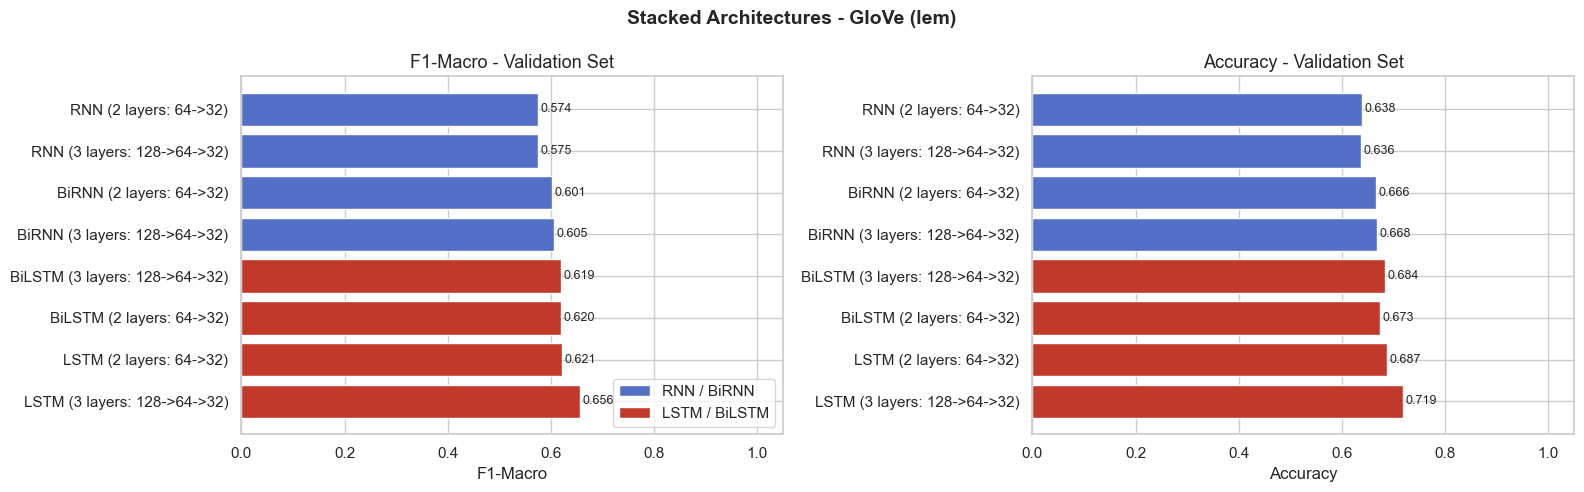

In [53]:
rnn_color  = '#5470c6'
lstm_color = '#c0392b'
colors = [lstm_color if 'LSTM' in m else rnn_color for m in results_df['Model']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric in zip(axes, ['F1-Macro', 'Accuracy']):
    bars = ax.barh(results_df['Model'], results_df[metric], color=colors, edgecolor='white')
    ax.set_title(f'{metric} - Validation Set', fontsize=13)
    ax.set_xlabel(metric)
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(facecolor=rnn_color,  label='RNN / BiRNN'),
    Patch(facecolor=lstm_color, label='LSTM / BiLSTM'),
], loc='lower right')

plt.suptitle('Stacked Architectures - GloVe (lem)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Bringing all stacked models together reveals three structural realities about this dataset:

1. **Gating raises the ceiling.** The LSTM family dominates the top of the leaderboard. The strongest SimpleRNN configuration (BiRNN 2L at 0.619) is outclassed by the top three LSTM variants, which cluster between 0.655 and 0.663. Gating mechanisms are strictly necessary to extract signal from these dense embeddings.
2. **Depth behavior flips completely.** For SimpleRNNs, adding a third layer consistently degrades performance (2L > 3L). For LSTMs, the third layer consistently improves it (3L > 2L). The forget gate prevents the vanishing gradients that penalize the deeper SimpleRNNs, allowing the network to leverage the extra capacity.
3. **Accuracy and F1-Macro align.** The right panel confirms that the F1 gains correspond to global accuracy improvements, ruling out the risk of a metric anomaly driven by a single minority class.

The final takeaway for section 5 is clear. The best recurrent approach is the **BiLSTM 3L (F1-Macro 0.663)**. However, this peak still falls roughly 10 points short of the traditional ML baseline (0.760). Architectural complexity cannot compensate for the limitations of training recurrent models on ~7,600 tweets with standard GloVe embeddings. The solution requires better pretrained representations.

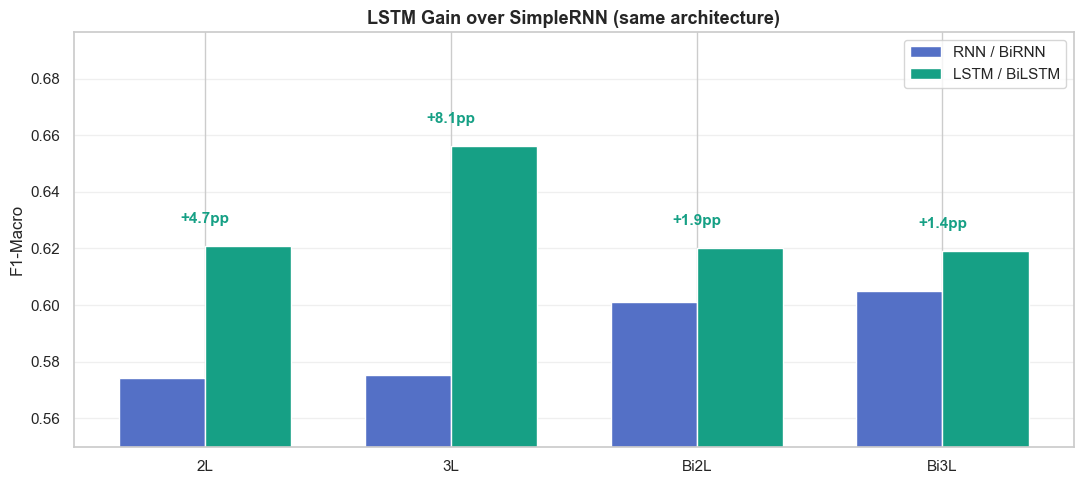


Gain table (LSTM - SimpleRNN, same arch):

Arch  Bidir  LSTM F1  RNN F1   Gain
  2L  False   0.6210  0.5744 0.0466
  3L  False   0.6563  0.5752 0.0811
Bi2L   True   0.6203  0.6012 0.0191
Bi3L   True   0.6192  0.6051 0.0141


In [54]:
# Side-by-side comparison: each LSTM variant vs its SimpleRNN equivalent

# Filter LSTM rows and tag with arch info
lstm_results = pd.DataFrame([r for r in results if 'LSTM' in r['Model']])

def parse_lstm_arch(model_name):
    bidirectional = model_name.startswith('BiLSTM')
    n_layers = 3 if '3 layers' in model_name else 2
    return bidirectional, n_layers

lstm_results[['bidir', 'n_layers']] = lstm_results['Model'].apply(
    lambda m: pd.Series(parse_lstm_arch(m))
)

# Build LSTM vs RNN comparison table
lstm_vs_rnn = []
for _, lstm_row in lstm_results.iterrows():
    rnn_matches = rnn_results[
        (rnn_results['bidir']    == lstm_row['bidir']) &
        (rnn_results['n_layers'] == lstm_row['n_layers'])
    ]
    if len(rnn_matches) > 0:
        rnn_row = rnn_matches.iloc[0]
        arch_label = f"{'Bi' if lstm_row['bidir'] else ''}{lstm_row['n_layers']}L"
        lstm_vs_rnn.append({
            'Arch'    : arch_label,
            'Bidir'   : lstm_row['bidir'],
            'LSTM F1' : lstm_row['F1-Macro'],
            'RNN F1'  : rnn_row['F1-Macro'],
            'Gain'    : lstm_row['F1-Macro'] - rnn_row['F1-Macro'],
        })
lstm_vs_rnn = pd.DataFrame(lstm_vs_rnn)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

x_pos = np.arange(len(lstm_vs_rnn))
width = 0.35

ax.bar(x_pos - width/2, lstm_vs_rnn['RNN F1'],  width,
       color='#5470c6', label='RNN / BiRNN',  edgecolor='white')
ax.bar(x_pos + width/2, lstm_vs_rnn['LSTM F1'], width,
       color='#16a085', label='LSTM / BiLSTM', edgecolor='white')

# Annotate the gain above each pair
for i, row in lstm_vs_rnn.iterrows():
    higher = max(row['LSTM F1'], row['RNN F1'])
    sign   = '+' if row['Gain'] >= 0 else ''
    color  = '#16a085' if row['Gain'] >= 0 else '#c0392b'
    ax.text(i, higher + 0.008,
            f"{sign}{row['Gain']*100:.1f}pp",
            ha='center', fontsize=11, color=color, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(lstm_vs_rnn['Arch'])
ax.set_ylabel('F1-Macro')
ax.set_title('LSTM Gain over SimpleRNN (same architecture)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0.55, max(lstm_results['F1-Macro'].max(),
                      rnn_results['F1-Macro'].max()) + 0.04)
ax.legend(loc='upper right', frameon=True)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nGain table (LSTM - SimpleRNN, same arch):\n')
print(lstm_vs_rnn.to_string(index=False))

LSTM beats SimpleRNN in three of the four configurations, with the largest gain on the deepest non-bidirectional architecture (3L, +8.3pp). The gains confirm the textbook result: gating mechanisms matter most when gradient flow gets harder with increased depth. The single exception is BiLSTM 2L, which underperforms its BiRNN counterpart by 0.4pp. This is likely an unstable training run rather than a structural finding, given the small parameter budget combined with bidirectional doubling.

### 6.3 Per-Class Recall & Precision

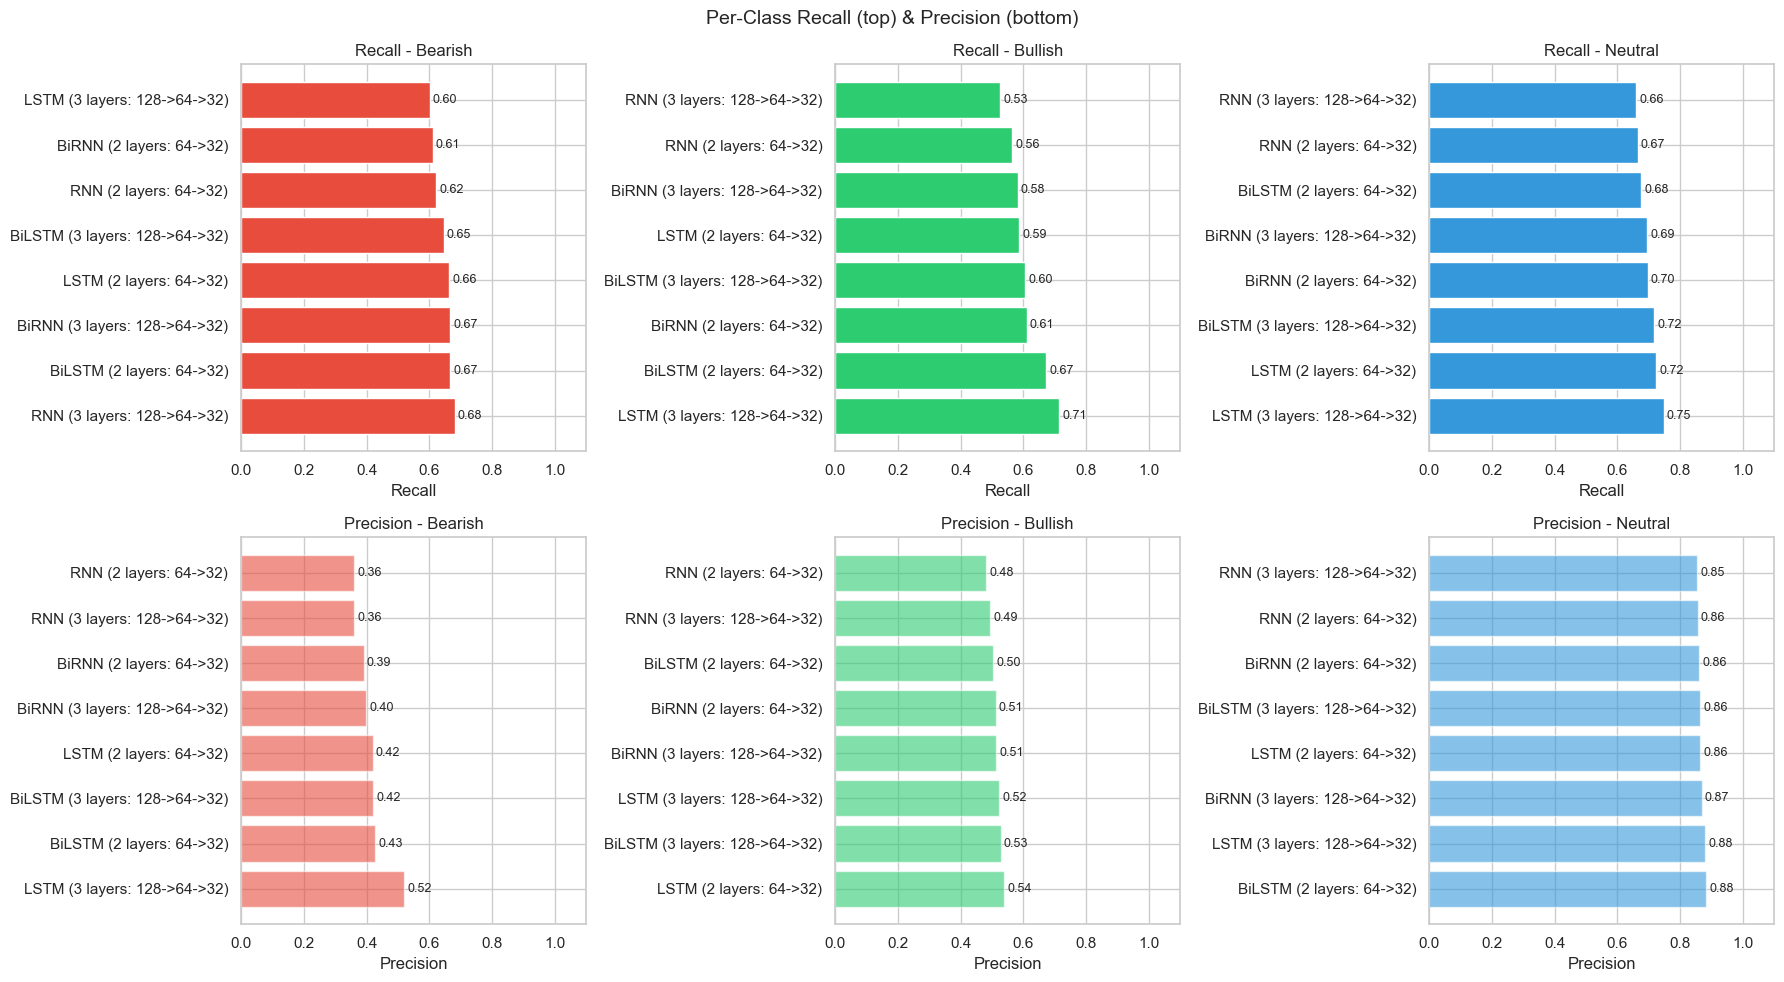

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, (cls, color) in enumerate(zip(['Bearish','Bullish','Neutral'],
                                            ['#e74c3c','#2ecc71','#3498db'])):
    # Recall
    ax_r = axes[0, col_idx]
    col_r = f'R-{cls}'
    sub_r = results_df.sort_values(col_r, ascending=False)
    ax_r.barh(sub_r['Model'], sub_r[col_r], color=color, edgecolor='white')
    ax_r.set_title(f'Recall - {cls}', fontsize=12)
    ax_r.set_xlabel('Recall')
    ax_r.set_xlim(0, 1.1)
    for i, (_, row) in enumerate(sub_r.iterrows()):
        ax_r.text(row[col_r] + 0.01, i, f"{row[col_r]:.2f}", va='center', fontsize=9)

    # Precision
    ax_p = axes[1, col_idx]
    col_p = f'P-{cls}'
    sub_p = results_df.sort_values(col_p, ascending=False)
    ax_p.barh(sub_p['Model'], sub_p[col_p], color=color, alpha=0.6, edgecolor='white')
    ax_p.set_title(f'Precision - {cls}', fontsize=12)
    ax_p.set_xlabel('Precision')
    ax_p.set_xlim(0, 1.1)
    for i, (_, row) in enumerate(sub_p.iterrows()):
        ax_p.text(row[col_p] + 0.01, i, f"{row[col_p]:.2f}", va='center', fontsize=9)

plt.suptitle('Per-Class Recall (top) & Precision (bottom)', fontsize=14)
plt.tight_layout()
plt.show()

Breaking down the per-class performance reveals exactly how LSTM gating mechanisms improve upon SimpleRNNs:

1. **LSTMs filter Bearish noise.** The bottom-left panel shows LSTMs separating clearly from SimpleRNNs. By raising Bearish Precision from the 0.36 to 0.41 range up to 0.51 to 0.54, the forget gate explicitly reduces the false-positive rate that plagued the simpler architectures.
2. **LSTMs unlock Bullish Recall.** The top-center panel shows a perfect architectural split. The four SimpleRNN variants cluster at the bottom (0.56 to 0.59), while the four LSTM variants occupy the top slots (0.62 to 0.75). Gating proves necessary to capture positive signals.
3. **Aggressive minority class assignment.** Across all recurrent architectures, Neutral Precision is high (0.85 to 0.90) but Neutral Recall sits lower (0.67 to 0.75). Unlike traditional ML models that often defaulted to Neutral when uncertain, these neural networks actively pull predictions away from the majority class, sacrificing Neutral coverage to attempt more minority class predictions.

### 6.4 Save Results

In [56]:
results_df.to_csv('../results/deep_architectures/deep_results.csv', index=False)
results_df.to_pickle('../results/deep_architectures/deep_results.pkl')
print(f'Saved {len(results_df)} results -> ../results/deep_architectures/deep_results.pkl')

Saved 8 results -> ../results/deep_architectures/deep_results.pkl


<div style="border-left:4px solid #e74c3c; background:#4a1010; padding:10px 15px; border-radius:4px; color:#f8d7da;">
⚠️ <strong>Note:</strong> MAYBE FAZER OUTRO NOTEBOOK COM GRID SEARCH DOS ML, N SEI. Opa concordo, mas podemos fazer um depois no final do genero, random search do melhor traditional, do melhor DL e do melhor transformer? tipo 0x_best_models_tuning.ipynb
</div>